In [1]:
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import scarf
import scarf.plotting as splt

scarf.configure_output(level="WARNING", progress=True)

dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    "tenx_5K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
    min_features_per_cell=10,
)
ds.filter_cells(
    attrs=["RNA_nCounts", "RNA_nFeatures", "RNA_percentMito"],
    highs=[15000, 4000, 15],
    lows=[1000, 500, 0],
    reset_previous=True,
)
if "I__hvgs" not in ds.RNA.feats.columns:
    ds.mark_hvgs(
        min_cells=20,
        top_n=500,
        show_plot=False,
    )
normalized = ds.run_normalization(feat_key="hvgs")

Downloading bucket files: 48216334 / 48216334 complete

Downloading bytes: 48216334 / 48216334 complete

Writing data: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

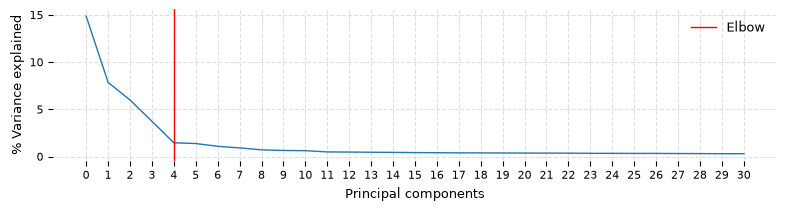

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Fitting PCA: 1 / 1 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

In [2]:
cluster_keys = {}
pca_refs = {}
for dimensions in (10, 30, 15):
    pca = ds.run_pca(
        normalized,
        dims=dimensions,
        show_elbow_plot=dimensions == 30,
    )
    pca_refs[dimensions] = pca
    if dimensions == 15:
        ds.build_embedding_initialization(pca)
    ann = ds.build_ann_index(pca)
    neighbors = ds.query_neighbors(ann, k=11)
    graph = ds.build_connectivity_map(neighbors)

    label = f"leiden_pca_{dimensions}"
    ds.run_leiden_clustering(
        graph,
        resolution=0.5,
        label=label,
    )
    cluster_keys[dimensions] = f"RNA_{label}"

In [3]:
scores_30 = np.asarray(ds.load_artifact(pca_refs[30])["data"])
retained_share = scores_30.var(axis=0, ddof=1)
retained_share = 100.0 * retained_share / retained_share.sum()
cumulative_share = np.cumsum(retained_share)
pd.Series(
    {
        dimensions: float(cumulative_share[dimensions - 1])
        for dimensions in (10, 15, 30)
    },
    name="cumulative_share_of_30pc_fit",
).rename_axis("pca_dimensions")

pca_dimensions
10     83.294792
15     88.609787
30    100.000000
Name: cumulative_share_of_30pc_fit, dtype: float64

In [4]:
cluster_counts = pd.Series(
    {
        dimensions: pd.Series(
            ds.cells.fetch(cluster_key, key="I")
        ).nunique()
        for dimensions, cluster_key in cluster_keys.items()
    },
    name="n_clusters",
).rename_axis("pca_dimensions")
cluster_counts

pca_dimensions
10    11
30    10
15    11
Name: n_clusters, dtype: int64

In [5]:
cluster_sizes = pd.DataFrame(
    {
        dimensions: pd.Series(
            ds.cells.fetch(cluster_key, key="I")
        ).value_counts()
        for dimensions, cluster_key in cluster_keys.items()
    }
).fillna(0).astype(int)
cluster_sizes

,10,30,15
1,740,1329,1261
2,724,702,699
3,527,626,670
4,495,315,318
5,442,287,299
6,332,260,252
7,252,237,246
8,246,144,143
9,155,25,25
10,15,15,15


In [6]:
agreement_rows = []
for first, second in combinations(cluster_keys, 2):
    columns = [cluster_keys[first], cluster_keys[second]]
    agreement_rows.append(
        {
            "comparison": f"{first} vs {second} dimensions",
            "ARI": ds.metric_label_concordance(
                columns,
                metric="ari",
            ),
            "NMI": ds.metric_label_concordance(
                columns,
                metric="nmi",
            ),
        }
    )
pd.DataFrame(agreement_rows)

,comparison,ARI,NMI
0,10 vs 30 dimensions,0.652591,0.806898
1,10 vs 15 dimensions,0.698997,0.848419
2,30 vs 15 dimensions,0.886776,0.897774


In [7]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    label="UMAP",
)

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='847eb5e3de88...')

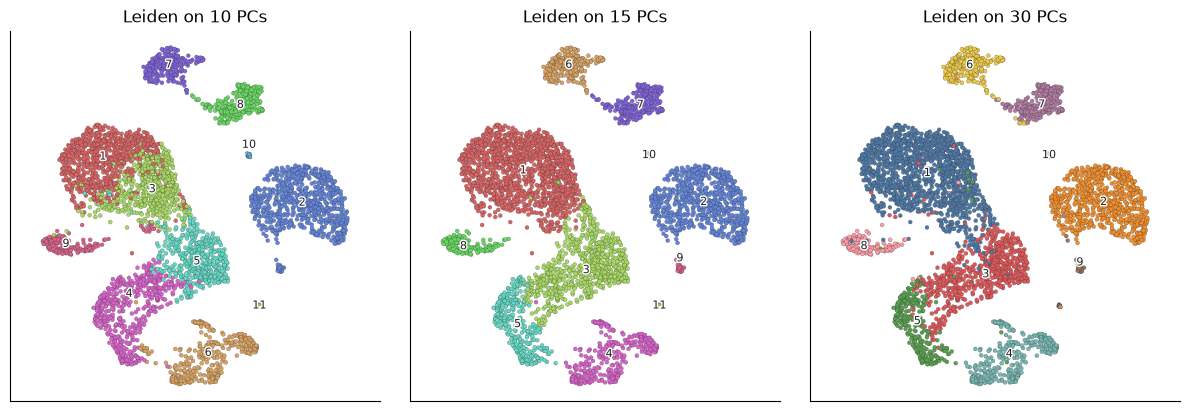

In [8]:
pca_partition_view = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=[cluster_keys[dimensions] for dimensions in (10, 15, 30)],
    n_columns=3,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, dimensions in zip(
    pca_partition_view.axes.values(),
    (10, 15, 30),
    strict=True,
):
    axis.set_title(f"Leiden on {dimensions} PCs")
pca_partition_view.figure.set_size_inches(12, 4)
pca_partition_view.figure

In [9]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=0.1,
    parallel=True,
    label="UMAP_tight",
)

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='903c5b877762...')

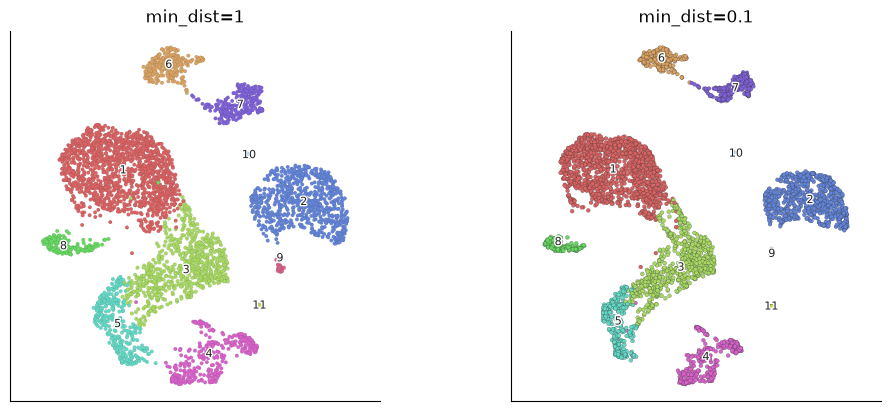

In [10]:
min_dist_view = ds.plots.embedding(
    layout_key=["RNA_UMAP", "RNA_UMAP_tight"],
    color_by=cluster_keys[15],
    n_columns=2,
    legend_loc="on_data",
    show_titles=False,
    show=False,
)
for axis, title in zip(
    min_dist_view.axes.values(),
    ("min_dist=1", "min_dist=0.1"),
    strict=True,
):
    axis.set_title(title)
min_dist_view.figure.set_size_inches(10, 4)
min_dist_view.figure

In [11]:
ds.run_umap(
    n_epochs=150,
    spread=5,
    min_dist=1,
    parallel=True,
    use_density_map=True,
    label="densMAP",
)

Training UMAP: 150 / 150 complete

ArtifactRef(assay='RNA', kind='embedding', artifact_id='899d94a2f183...')

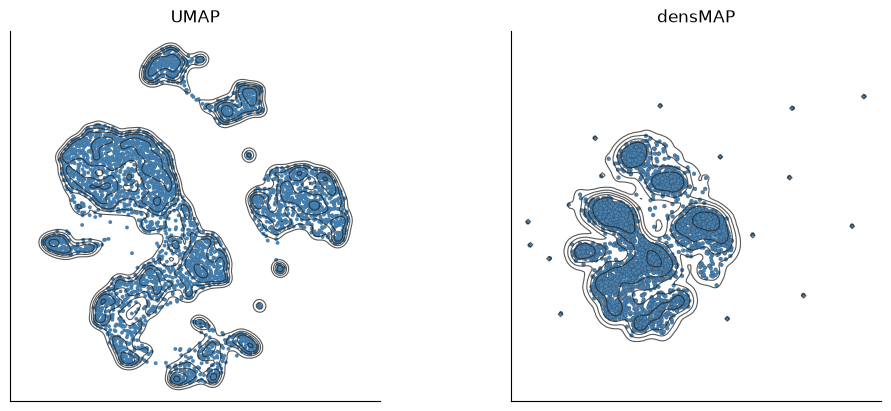

In [12]:
density_contrast = ds.plots.embedding(
    layout_key=["RNA_UMAP", "RNA_densMAP"],
    color_by=None,
    n_columns=2,
    density_overlay=splt.DensityOverlay(statistic="density"),
    show_legend=False,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    density_contrast.axes.values(),
    ("UMAP", "densMAP"),
    strict=True,
):
    axis.set_title(title)
density_contrast.figure.set_size_inches(10, 4)
density_contrast.figure

In [13]:
ds.run_tsne(
    alpha=10,
    box_h=1,
    early_iter=250,
    max_iter=500,
    verbose=False,
)

ArtifactRef(assay='RNA', kind='embedding', artifact_id='0dbd0933e3e2...')

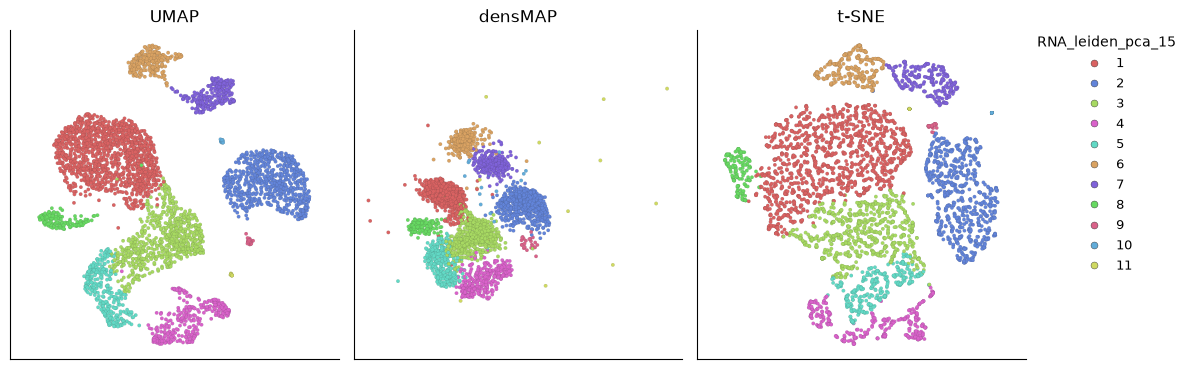

In [14]:
figure, axes = plt.subplots(1, 3, figsize=(12, 4))
layout_comparisons = (
    ("UMAP", "RNA_UMAP"),
    ("densMAP", "RNA_densMAP"),
    ("t-SNE", "RNA_tSNE"),
)
for index, (axis, (title, layout_key)) in enumerate(
    zip(axes, layout_comparisons, strict=True)
):
    ds.plots.embedding(
        layout_key=layout_key,
        color_by=cluster_keys[15],
        legend_loc="right",
        show_legend=index == 2,
        show_titles=False,
        target=axis,
        show=False,
    )
    axis.set_title(title)
figure.tight_layout()
figure